Simulation examples for validation chapter


In [2]:
import time
import pymc as pm
import arviz as az
from scipy.stats import (
    norm, lognorm, uniform, cauchy, 
    poisson, nbinom, bernoulli,
    binom
)
from scipy.optimize import minimize

from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

IMAGE_DIR = Path('../../book/book/images')

/Users/poldrack/Dropbox/code/BetterCodeBetterScience/bettercode/.venv/lib/python3.13/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
rng = np.random.default_rng()
rng.uniform(size=10)

array([0.56449692, 0.6880841 , 0.43249236, 0.28950554, 0.02708363,
       0.61239335, 0.30663968, 0.3854357 , 0.57454511, 0.07974661])

Figure for uniform random variates

In [4]:
uniform_samples = rng.uniform(size=10000000)

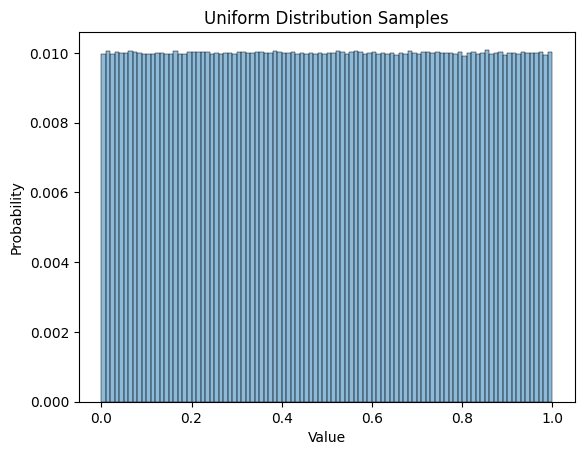

In [5]:

sns.histplot(uniform_samples, bins=100, alpha=0.5, stat='probability')
plt.title('Uniform Distribution Samples')
plt.xlabel('Value')
plt.ylabel('Probability')
plt.savefig(IMAGE_DIR / 'uniform_distribution.png')

Create a plot of several different distributions.

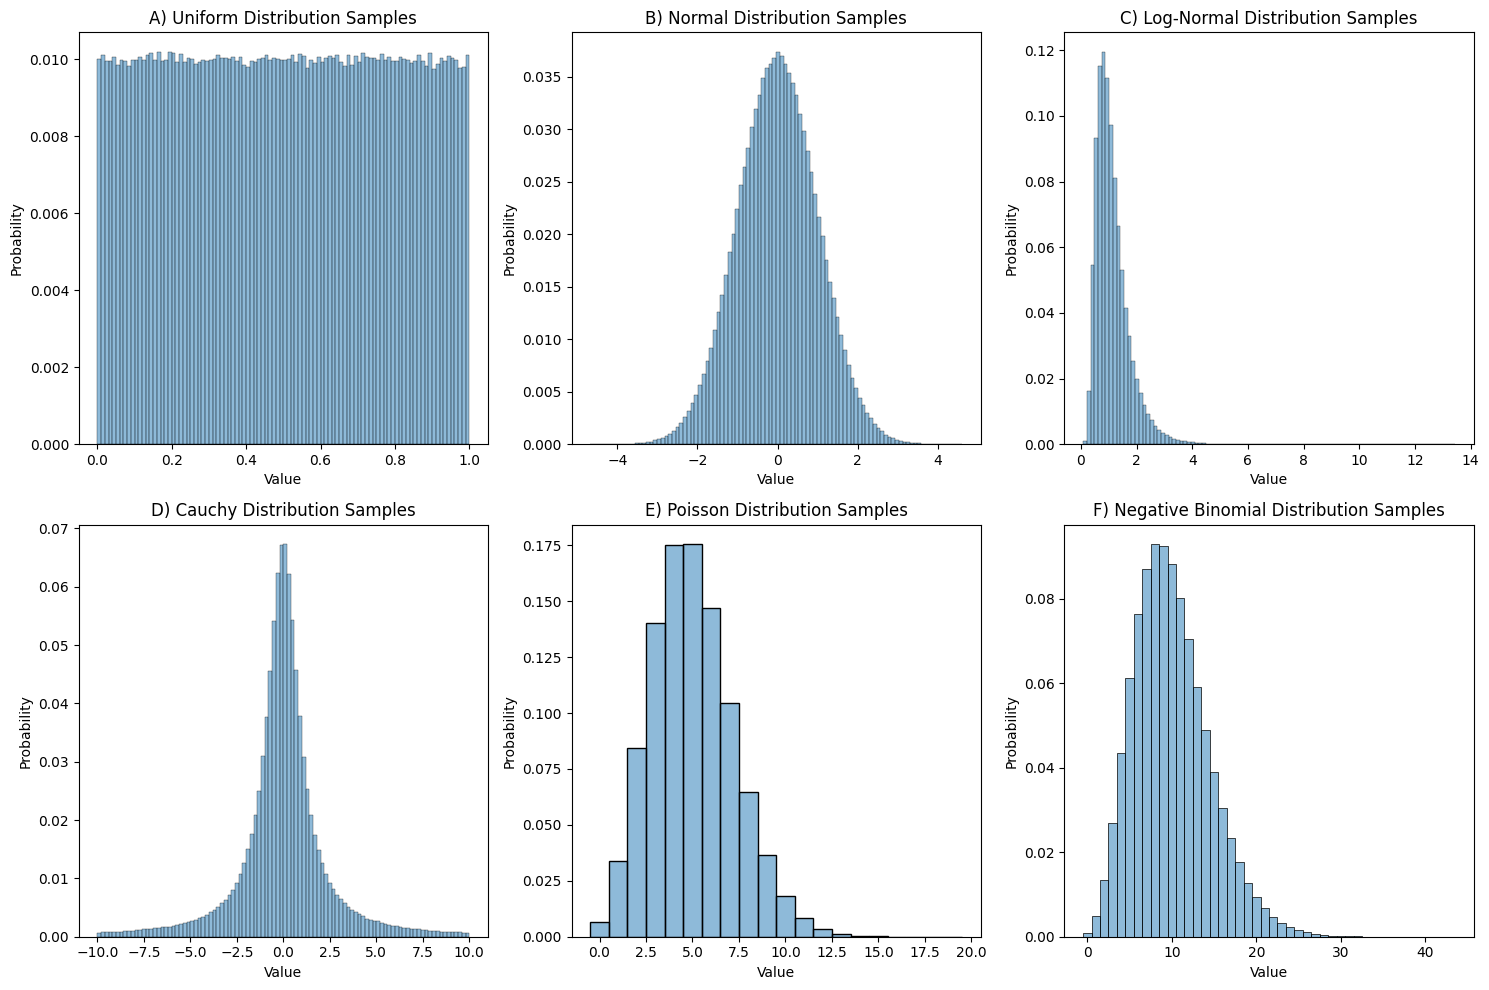

In [6]:

# Generate samples
n_samples = 1000000
distributions = {
    'Uniform': rng.uniform(size=n_samples),
    'Normal': rng.normal(size=n_samples),
    'Log-Normal': rng.lognormal(mean=0, sigma=0.5, size=n_samples),
    'Cauchy': rng.standard_cauchy(size=n_samples),
    'Poisson': rng.poisson(lam=5, size=n_samples),
    'Negative Binomial': rng.negative_binomial(n=10, p=0.5, size=n_samples)
}

# Create 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Panel labels
panel_labels = ['A', 'B', 'C', 'D', 'E', 'F']

for idx, (name, samples) in enumerate(distributions.items()):
    ax = axes[idx]
    
    # Adjust bins and xlim for different distributions
    if name == 'Cauchy':
        # Cauchy has heavy tails, limit the range for visualization
        samples_trimmed = samples[(samples > -10) & (samples < 10)]
        sns.histplot(samples_trimmed, bins=100, alpha=0.5, stat='probability', ax=ax)
    elif name in ['Poisson', 'Negative Binomial']:
        # Discrete distributions
        sns.histplot(samples, bins=30, alpha=0.5, stat='probability', discrete=True, ax=ax)
    else:
        sns.histplot(samples, bins=100, alpha=0.5, stat='probability', ax=ax)
    
    ax.set_title(f'{panel_labels[idx]}) {name} Distribution Samples')
    ax.set_xlabel('Value')
    ax.set_ylabel('Probability')

plt.tight_layout()
plt.savefig(IMAGE_DIR / 'multiple_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# example draws from distributions mentioned in the text:

size = 1000
distributions = {
    'Bernoulli': rng.binomial(n=1, p=0.3, size=size),
    'Binomial': rng.binomial(n=10, p=0.5, size=size),
    'Normal': rng.normal(size=size),
    'Log-Normal': rng.lognormal(mean=0, sigma=0.5, size=size),
    'Uniform': rng.uniform(size=size),
    'Cauchy': rng.standard_cauchy(size=size),
    'Poisson': rng.poisson(lam=5, size=size),
    'Negative Binomial': rng.negative_binomial(n=10, p=0.5, size=size),
}

for name, samples in distributions.items():
    print(f"{name} samples:\n{samples[:10]}\n")  # Print first 10 samples for each distribution

Bernoulli samples:
[0 0 0 0 0 0 0 1 0 1]

Binomial samples:
[5 5 4 4 4 5 4 6 6 4]

Normal samples:
[ 0.84775719 -0.09571624 -0.58748284 -0.09869641  0.91224671 -0.55028772
  1.03932866 -2.6431964   1.02520201  0.33971322]

Log-Normal samples:
[1.00055395 1.34134058 0.40153555 1.74151257 0.76036668 1.25907225
 0.84568224 0.77798138 0.49958991 0.76137519]

Uniform samples:
[0.64440648 0.35524344 0.60068849 0.72108827 0.99529389 0.39519375
 0.40171159 0.77268128 0.84458542 0.68145188]

Cauchy samples:
[-0.11268867 -3.28550182  2.72544181  1.82063032  0.24586197  3.66801462
 -2.62123783 -0.39511079 -6.130586    0.67593483]

Poisson samples:
[5 8 3 4 4 4 9 5 2 6]

Negative Binomial samples:
[ 7 13 14 14  5 15  8 13  5  9]



In [ ]:
### seeds
rng = np.random.default_rng(seed=42)
rng.uniform(size=4)



array([0.77395605, 0.43887844, 0.85859792, 0.69736803])

In [9]:
rng.uniform(size=4)

array([0.09417735, 0.97562235, 0.7611397 , 0.78606431])

In [12]:
rng2 = np.random.default_rng(seed=42)
rng2.uniform(size=4)

array([0.77395605, 0.43887844, 0.85859792, 0.69736803])

In [13]:
rng2.uniform(size=4)    

array([0.09417735, 0.97562235, 0.7611397 , 0.78606431])

## estimating parameters

In [7]:
sample_size = 1000

# set up numpy random state
random_state = np.random.default_rng(42)

# True population parameters (using standard normal)
true_mean = 0
true_sd = 1

# take sample
normal_samples = norm.rvs(loc=true_mean, scale=true_sd, size=sample_size, random_state=random_state)


In [8]:
# compute mean by hand
start_time = time.time()
sample_mean = np.sum(normal_samples) / sample_size
assert sample_mean == np.mean(normal_samples)

# compute sd by hand
squared_diffs = (normal_samples - sample_mean) ** 2
sample_variance = np.sum(squared_diffs) / (sample_size - 1)
sample_sd = np.sqrt(sample_variance)
assert sample_sd == np.std(normal_samples, ddof=1)
elapsed_time_cf = time.time() - start_time
print(elapsed_time_cf)


0.00018930435180664062


In [9]:
# compute confidence interval using t distribution
from scipy.stats import t

# Calculate 95% confidence interval
confidence_level = 0.95
alpha = 1 - confidence_level
degrees_of_freedom = sample_size - 1

# Get the critical t-value
t_critical = t.ppf(1 - alpha/2, degrees_of_freedom)

# Calculate standard error
standard_error = sample_sd / np.sqrt(sample_size)

# Calculate margin of error
margin_of_error = t_critical * standard_error

# Calculate confidence interval
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"Sample mean: {sample_mean:.5f}")
print(f"Sample SD: {sample_sd:.5f}")
print(f"Standard error: {standard_error:.5f}")
print(f"t-critical value (df={degrees_of_freedom}): {t_critical:.5f}")
print(f"95% Confidence Interval: [{ci_lower:.5f}, {ci_upper:.5f}]")

Sample mean: -0.02889
Sample SD: 0.98922
Standard error: 0.03128
t-critical value (df=999): 1.96234
95% Confidence Interval: [-0.09028, 0.03249]


In [10]:
# simulate to confirm that the CI captures the true population mean 95% of the time in new samples from the same distribution



# Simulation parameters
n_simulations = 100000
confidence_level = 0.95
alpha = 1 - confidence_level

# Track how many times the CI captures the true mean
captures = 0

# Run simulations
for i in range(n_simulations):
    # Draw a new sample from the population
    sample = norm.rvs(loc=true_mean, scale=true_sd, 
        size=sample_size, random_state=random_state)
    
    # Calculate sample statistics
    sample_mean_sim = np.mean(sample)
    sample_sd_sim = np.std(sample, ddof=1)
    
    # Calculate confidence interval
    df = sample_size - 1
    t_crit = t.ppf(1 - alpha/2, df)
    se = sample_sd_sim / np.sqrt(sample_size)
    margin = t_crit * se
    
    ci_low = sample_mean_sim - margin
    ci_high = sample_mean_sim + margin
    
    # Check if CI captures the true mean
    if ci_low <= true_mean <= ci_high:
        captures += 1

# Calculate coverage rate
coverage_rate = captures / n_simulations

print(f"Simulation results:")
print(f"Number of simulations: {n_simulations}")
print(f"Sample size per simulation: {sample_size}")
print(f"True population mean: {true_mean}")
print(f"Confidence level: {confidence_level * 100}%")
print(f"\nCoverage rate: {coverage_rate:.4f} ({coverage_rate * 100:.2f}%)")
print(f"Number of times CI captured true mean: {captures} out of {n_simulations}")
print(f"\nExpected coverage: {confidence_level * 100}%")
print(f"Difference from expected: {(coverage_rate - confidence_level) * 100:.2f}%")

Simulation results:
Number of simulations: 100000
Sample size per simulation: 1000
True population mean: 0
Confidence level: 95.0%

Coverage rate: 0.9496 (94.97%)
Number of times CI captured true mean: 94965 out of 100000

Expected coverage: 95.0%
Difference from expected: -0.03%


In [11]:
## Bootstrap estimate of confidence interval using scipy.stats.bootstrap

from scipy.stats import bootstrap
res = bootstrap((normal_samples,), np.mean, confidence_level=0.95,      
    n_resamples=10000, method='BCa', random_state=random_state)

print(f'Bootstrap 95% CI for mean: '
    f'[{res.confidence_interval.low:.5f}, '
    f'{res.confidence_interval.high:.5f}]')
print(f'CI based on t-distribution: [{ci_lower:.5f}, {ci_upper:.5f}]')

Bootstrap 95% CI for mean: [-0.09104, 0.03078]
CI based on t-distribution: [-0.09028, 0.03249]


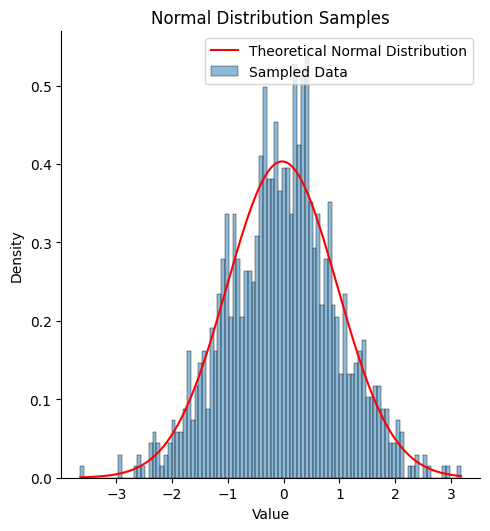

In [12]:
sns.displot(normal_samples, bins=100, alpha=0.5, stat='density')
# overlay theoretical normal distribution curve
x = np.linspace(min(normal_samples), max(normal_samples), 1000)
pdf = (1 / (sample_sd * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - sample_mean) / sample_sd) ** 2)
plt.plot(x, pdf, color='red')

plt.title('Normal Distribution Samples')
plt.xlabel('Value')
plt.ylabel('Density')
# add a legend for the histogram and the theoretical curve
plt.legend(['Theoretical Normal Distribution', 'Sampled Data'])

plt.savefig(IMAGE_DIR / 'normal_distribution.png', dpi=150, bbox_inches='tight')


In [23]:
# do a grid search for mean and sd to find best fit
def normal_params_grid_search(data, mean_grid=None, sd_grid=None):
    if mean_grid is None:
        mean_grid = np.linspace(-1, 1, 1000)
    if sd_grid is None:
        sd_grid = np.linspace(0.5, 1.5, 1000)

    log_likelihoods = np.zeros((len(mean_grid), len(sd_grid)))
    for i, mu in enumerate(mean_grid):
        for j, sd in enumerate(sd_grid):
            # compute log likelihood for current mu and sd
            log_likelihoods[i, j] = norm.logpdf(data, loc=mu, scale=sd).sum()


    # find the parameters that maximize the log likelihood
    max_idx = np.unravel_index(np.argmax(log_likelihoods), log_likelihoods.shape)
    best_mean = mean_grid[max_idx[0]]
    best_sd = sd_grid[max_idx[1]]

    return best_mean, best_sd, log_likelihoods, mean_grid, sd_grid

start_time = time.time()
best_mean, best_sd, log_likelihoods, mean_grid, sd_grid = normal_params_grid_search(normal_samples)
elapsed_time_grid = time.time() - start_time




In [14]:
best_fit_ll = norm.logpdf(normal_samples, loc=best_mean, scale=best_sd).sum()
pop_sd = np.std(normal_samples, ddof=0)
sample_ll = norm.logpdf(normal_samples, loc=sample_mean, 
    scale=pop_sd).sum()

print(f"Execution time: {elapsed_time_grid:.4f} seconds")
print(f'Execution time versus closed form: {elapsed_time_grid/elapsed_time_cf} times slower')
print(f"Best fit mean: {best_mean:0.4f}, Best fit sd: {best_sd:0.4f}, loglik: {best_fit_ll:0.4f}")
print(f"Sample mean: {sample_mean:0.4f}, Population sd: {pop_sd:0.4f}, loglik: {sample_ll:0.4f}")


Execution time: 25.2965 seconds
Execution time versus closed form: 133628.88287153654 times slower
Best fit mean: -0.0290, Best fit sd: 0.9885, loglik: -1407.5969
Sample mean: -0.0289, Population sd: 0.9887, loglik: -1407.5968


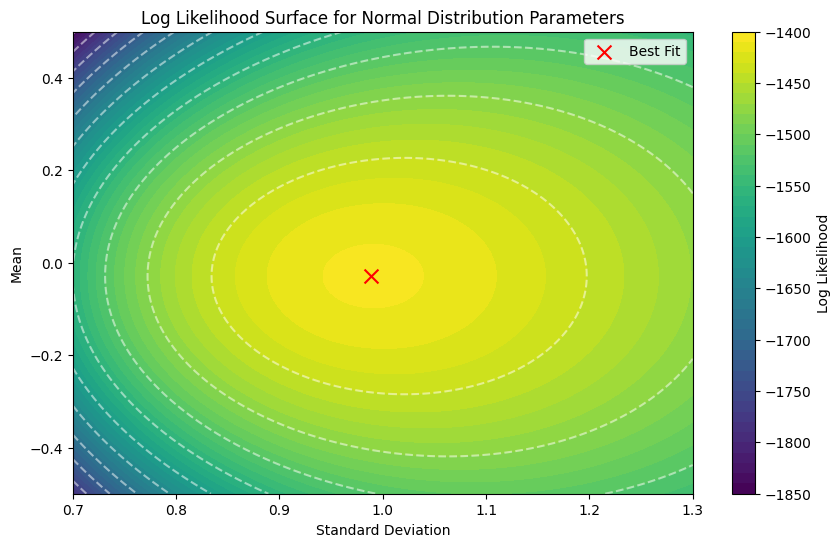

In [ ]:
# plot the log likelihood surface using a broader range of values
mean_grid = np.linspace(-.5, .5, 1000)
sd_grid = np.linspace(0.7, 1.3, 1000)
best_mean_vis, best_sd_vis, log_likelihoods_vis, mean_grid, sd_grid = normal_params_grid_search(normal_samples, mean_grid=mean_grid, sd_grid=sd_grid)

plt.figure(figsize=(10, 6))
X, Y = np.meshgrid(sd_grid, mean_grid)
plt.contourf(X, Y, log_likelihoods_vis, levels=50, cmap='viridis')
plt.colorbar(label='Log Likelihood')
plt.scatter(best_sd_vis, best_mean_vis, color='red', label='Best Fit', marker='x', s=100)
plt.xlabel('Standard Deviation')
plt.ylabel('Mean')
plt.title('Log Likelihood Surface for Normal Distribution Parameters')
plt.legend()
# add contour lines
plt.contour(X, Y, log_likelihoods_vis, levels=10, colors='white', alpha=0.5)
plt.savefig(IMAGE_DIR / 'normal_log_likelihood_surface.png', dpi=150, bbox_inches='tight')
plt.show()


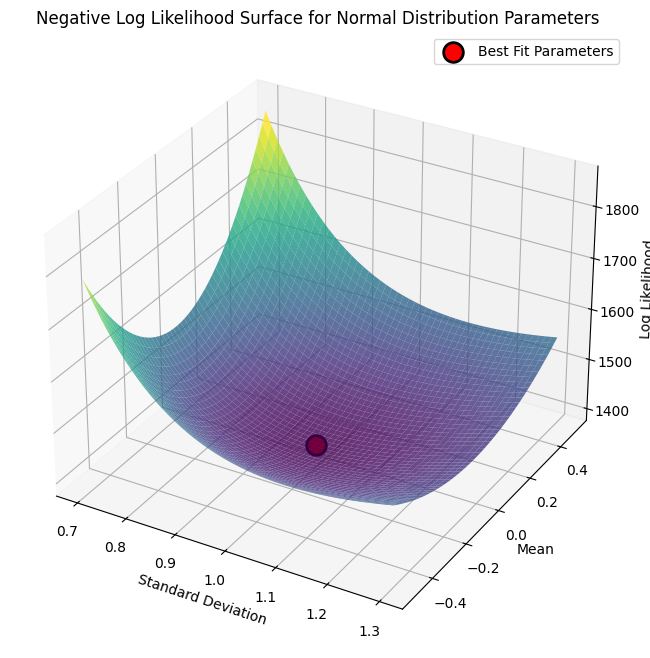

In [45]:
# generate a surface plot of the log likelihoods
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(sd_grid, mean_grid)
ax.plot_surface(X, Y, -1*log_likelihoods_vis, cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_xlabel('Standard Deviation')
ax.set_ylabel('Mean')
ax.set_zlabel('Log Likelihood')
ax.set_title('Negative Log Likelihood Surface for Normal Distribution Parameters')
# add contour lines on the bottom plane
ax.contour(X, Y, -1* log_likelihoods_vis, zdir='z', offset=np.min(log_likelihoods_vis), levels=10, colors='blue', alpha=0.5)
# add a point on the bottom plane showing best fit parameter values
ax.scatter(best_sd_vis, best_mean_vis, np.min(-1*log_likelihoods_vis), color='red', s=200, marker='o', edgecolors='black', linewidths=2, label='Best Fit Parameters', zorder=10)
ax.legend()

plt.savefig(IMAGE_DIR / 'normal_log_likelihood_surface_3d.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# use optimization to find best fit parameters

def negative_log_likelihood(params, data):
    """Negative log likelihood function to minimize"""
    mu, sd = params
    if sd <= 0:  # ensure sd is positive
        return np.inf
    return -norm.logpdf(data, loc=mu, scale=sd).sum()

# initial guess
initial_params = [0, 1]

start_time = time.time()
result = minimize(negative_log_likelihood, initial_params, args=(normal_samples,), 
                  method='Nelder-Mead')
elapsed_time_opt = time.time() - start_time

opt_mean, opt_sd = result.x
opt_ll = -result.fun

print(f"Optimization time: {elapsed_time_opt:.4f} seconds")
print(f'Optimization time versus grid search: {elapsed_time_grid/elapsed_time_opt:.4f} times faster')
print(f'Optimization time versus closed form: {elapsed_time_opt/elapsed_time_cf:.4f} times slower')
print(f"Optimized mean: {opt_mean:0.5f}, Optimized sd: {opt_sd:0.5f}, loglik: {opt_ll:0.5f}")
print(f"Sample mean: {sample_mean:0.5f}, Population sd: {pop_sd:0.5f}, loglik: {sample_ll:0.5f}")


Optimization time: 0.0115 seconds
Optimization time versus grid search: 2204.1076 times faster
Optimization time versus closed form: 60.6272 times slower
Optimized mean: -0.02889, Optimized sd: 0.98874, loglik: -1407.59681
Sample mean: -0.02889, Population sd: 0.98872, loglik: -1407.59681


In [16]:
# use really bad initial guesses
initial_params = [10000, 10000]

start_time = time.time()
result = minimize(negative_log_likelihood, initial_params, args=(normal_samples,), 
                  method='Nelder-Mead')
elapsed_time_opt_bad = time.time() - start_time

opt_mean, opt_sd = result.x
opt_ll = -result.fun

print(f"Optimization time: {elapsed_time_opt_bad:.4f} seconds")
print(f'Optimization time versus grid search: {elapsed_time_grid/elapsed_time_opt_bad:.4f} times faster')
print(f'Optimization time versus closed form: {elapsed_time_opt_bad/elapsed_time_cf:.4f} times slower')
print(f"Optimized mean: {opt_mean:0.5f}, Optimized sd: {opt_sd:0.5f}, loglik: {opt_ll:0.5f}")
print(f"Sample mean: {sample_mean:0.5f}, Population sd: {pop_sd:0.5f}, loglik: {sample_ll:0.5f}")


Optimization time: 0.0101 seconds
Optimization time versus grid search: 2504.8712 times faster
Optimization time versus closed form: 53.3476 times slower
Optimized mean: -0.02893, Optimized sd: 0.98877, loglik: -1407.59682
Sample mean: -0.02889, Population sd: 0.98872, loglik: -1407.59681


In [17]:
# create a version with boundaries on sd parameter in the optimzation
from scipy.optimize import Bounds

# Define bounds: mean unbounded, sd must be positive
bounds = Bounds(lb=[-np.inf, 0], ub=[np.inf, np.inf])

# use really bad initial guesses
initial_params = [0, 1]

start_time = time.time()
result = minimize(negative_log_likelihood, initial_params, args=(normal_samples,), 
                  method='L-BFGS-B', bounds=bounds)
elapsed_time_opt_bounded = time.time() - start_time

opt_mean, opt_sd = result.x
opt_ll = -result.fun

print(f"Optimization time with bounds: {elapsed_time_opt_bounded:.4f} seconds")
print(f'Optimization time versus grid search: {elapsed_time_grid/elapsed_time_opt_bounded:.4f} times faster')
print(f'Optimization time versus closed form: {elapsed_time_opt_bounded/elapsed_time_cf:.4f} times slower')
print(f"Optimized mean: {opt_mean:0.5f}, Optimized sd: {opt_sd:0.5f}, loglik: {opt_ll:0.5f}")
print(f"Sample mean: {sample_mean:0.5f}, Population sd: {pop_sd:0.5f}, loglik: {sample_ll:0.5f}")

Optimization time with bounds: 0.0027 seconds
Optimization time versus grid search: 9524.3566 times faster
Optimization time versus closed form: 14.0302 times slower
Optimized mean: -0.02889, Optimized sd: 0.98872, loglik: -1407.59681
Sample mean: -0.02889, Population sd: 0.98872, loglik: -1407.59681


### Bayesian estimation

In [18]:


start_time = time.time()

# Bayesian estimation using PyMC
with pm.Model() as model:
    # Priors for unknown model parameters
    mu = pm.Normal('mu', mu=0, sigma=1000)  # Prior for mean
    sigma = pm.HalfNormal('sigma', sigma=100)  # Prior for standard deviation (must be positive)
    
    # Likelihood (sampling distribution) of observations
    likelihood = pm.Normal('likelihood', mu=mu, sigma=sigma, observed=normal_samples)
    
    # Posterior sampling
    trace = pm.sample(10000, tune=1000, return_inferencedata=True, random_seed=42)

# Extract posterior estimates
posterior_mean = trace.posterior['mu'].mean().values
posterior_sd = trace.posterior['sigma'].mean().values

# extract highest density interval
hdi = az.hdi(trace, hdi_prob=0.95)
hdi_values = hdi.mu.values

elapsed_time_bayes = time.time() - start_time


print(f"Bayesian estimation time: {elapsed_time_bayes:.4f} seconds")
print(f'Bayesian time versus optimization: {elapsed_time_bayes/elapsed_time_opt:.4f} times slower')
print(f'Bayesian time versus grid search: {elapsed_time_bayes/elapsed_time_grid:.4f} times slower')
print(f"Posterior mean: {posterior_mean:.5f}, Posterior sd: {posterior_sd:.5f}")
print(f"Sample mean: {sample_mean:.5f}, Sample sd: {sample_sd:.5f}")
print(f'95% HDI values: {hdi_values}')
print(f'95% CI based on t-distribution: [{ci_lower:.5f}, {ci_upper:.5f}]')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 1 seconds.


Bayesian estimation time: 2.2677 seconds
Bayesian time versus optimization: 197.5891 times slower
Bayesian time versus grid search: 0.0896 times slower
Posterior mean: -0.02895, Posterior sd: 0.99033
Sample mean: -0.02889, Sample sd: 0.98922
95% HDI values: [-0.08993754  0.03335397]
95% CI based on t-distribution: [-0.09028, 0.03249]


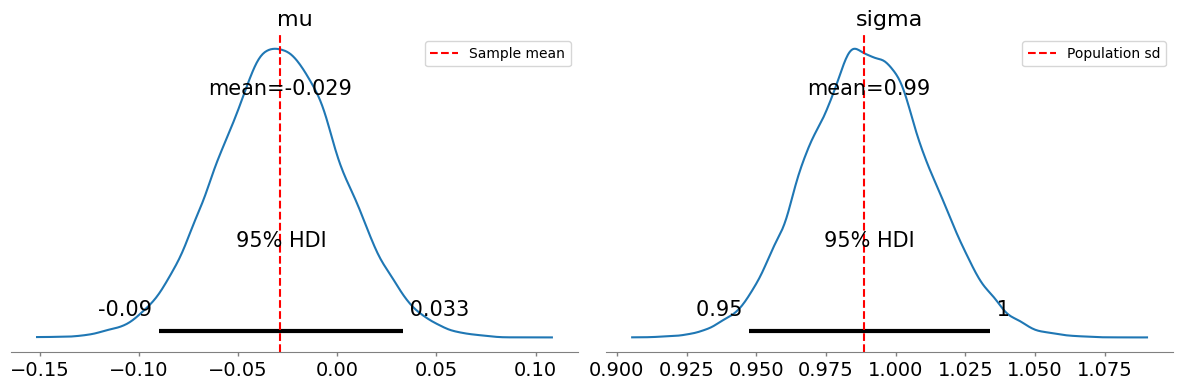

In [19]:
# Visualize posterior distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot posterior for mu
az.plot_posterior(trace, var_names=['mu'], ax=axes[0], hdi_prob=0.95)
axes[0].axvline(sample_mean, color='red', linestyle='--', label='Sample mean')
axes[0].legend()

# Plot posterior for sigma
az.plot_posterior(trace, var_names=['sigma'], ax=axes[1], hdi_prob=0.95)
axes[1].axvline(pop_sd, color='red', linestyle='--', label='Population sd')
axes[1].legend()

plt.tight_layout()
plt.savefig(IMAGE_DIR / 'bayesian_posterior.png', dpi=150, bbox_inches='tight')
plt.show()


### Simulating data from a model

In [62]:
# Simulation to test clustering algorithm performance
from sklearn.datasets import make_blobs
from sklearn.cluster import OPTICS
from dataclasses import dataclass
import pandas as pd

@dataclass
class SimulationParams:
    n_simulations: int = 100
    n_samples: int = 300
    n_features: int = 20
    cluster_std: float = 3.0
    optics_min_samples: int = 10
    optics_xi: float = 0.05
    optics_min_cluster_size: float = 0.05

params = SimulationParams()

def run_clustering_simulation(params: SimulationParams, true_n_clusters: int, seed: int):
    # Generate synthetic data with known number of clusters
    X, y_true = make_blobs(
        n_samples=params.n_samples,
        n_features=params.n_features,
        centers=true_n_clusters,
        cluster_std=params.cluster_std,
        random_state=seed
    )
    
    # Apply OPTICS clustering
    clustering = OPTICS(
        min_samples=params.optics_min_samples, 
        xi=params.optics_xi, 
        min_cluster_size=params.optics_min_cluster_size
    )
    y_pred = clustering.fit_predict(X)
    
    # Count number of clusters found (excluding noise points labeled as -1)
    predicted_n_clusters = len(set(y_pred)) - (1 if -1 in y_pred else 0)
    return predicted_n_clusters



# Test different numbers of clusters
n_clusters_range = range(2, 21)  # Test 2 to 20 clusters
results = []

for true_n_clusters in n_clusters_range:  
    for sim in range(n_simulations):
        # Generate synthetic data with known number of clusters
        predicted_n_clusters = run_clustering_simulation(
            params, true_n_clusters, seed=sim)        
        # Check if correct number of clusters was identified
        results.append({
            'sim_number': sim,
            'true_n_clusters': true_n_clusters,
            'predicted_n_clusters': predicted_n_clusters,
            'correct': predicted_n_clusters == true_n_clusters
        })
    
results_df = pd.DataFrame(results)

# Summary
print(f"\nOverall performance:")
overall_accuracy = results_df['correct'].mean()
print(f"Overall accuracy: {overall_accuracy:.2%}")



Overall performance:
Overall accuracy: 65.74%


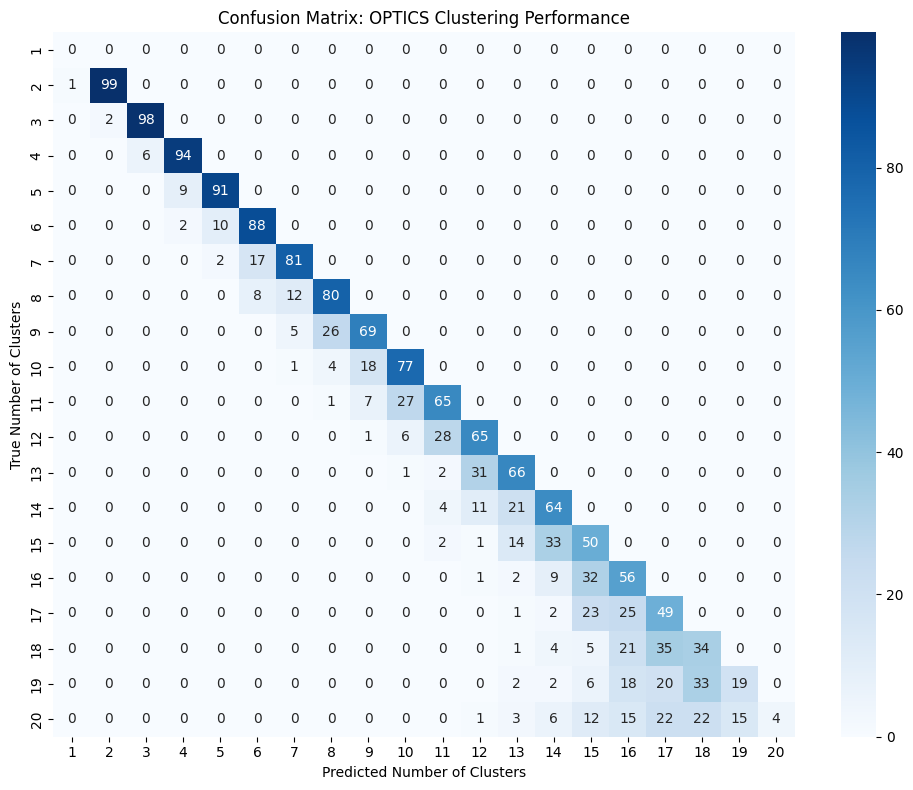


Confusion Matrix Shape: (20, 20)
Total simulations: 1900
Correctly identified (diagonal): 1249
Overall accuracy: 65.74%


In [63]:
# Create confusion matrix
from sklearn.metrics import confusion_matrix

# Compute confusion matrix from results_df
cm = confusion_matrix(results_df['true_n_clusters'], results_df['predicted_n_clusters'])

# Create figure
# use min/max of combined true/predicted labels for tick labels - same on each axis
min_label = min(results_df['true_n_clusters'].min(), results_df['predicted_n_clusters'].min())
max_label = max(results_df['true_n_clusters'].max(), results_df['predicted_n_clusters'].max())
ticklabels = range(min_label, max_label + 1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=ticklabels, 
            yticklabels=ticklabels)
ax.set_xlabel('Predicted Number of Clusters')
ax.set_ylabel('True Number of Clusters')
ax.set_title('Confusion Matrix: OPTICS Clustering Performance')

plt.tight_layout()
plt.savefig(IMAGE_DIR / 'clustering_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print some statistics
print(f"\nConfusion Matrix Shape: {cm.shape}")
print(f"Total simulations: {cm.sum()}")
print(f"Correctly identified (diagonal): {np.trace(cm)}")
print(f"Overall accuracy: {np.trace(cm) / cm.sum():.2%}")


## graphical modeling

- use the graph structure from ecoli70 (https://www.bnlearn.com/bnrepository/gaussian-medium.html#ecoli70) via pgmpy
- convert to a tigramite model for data generation
- generate timeseries from the graph structure
- use PCMPI to perform causal discovery
- compare to ground truth

46 nodes in the E. coli model.
70 edges in the E. coli model.


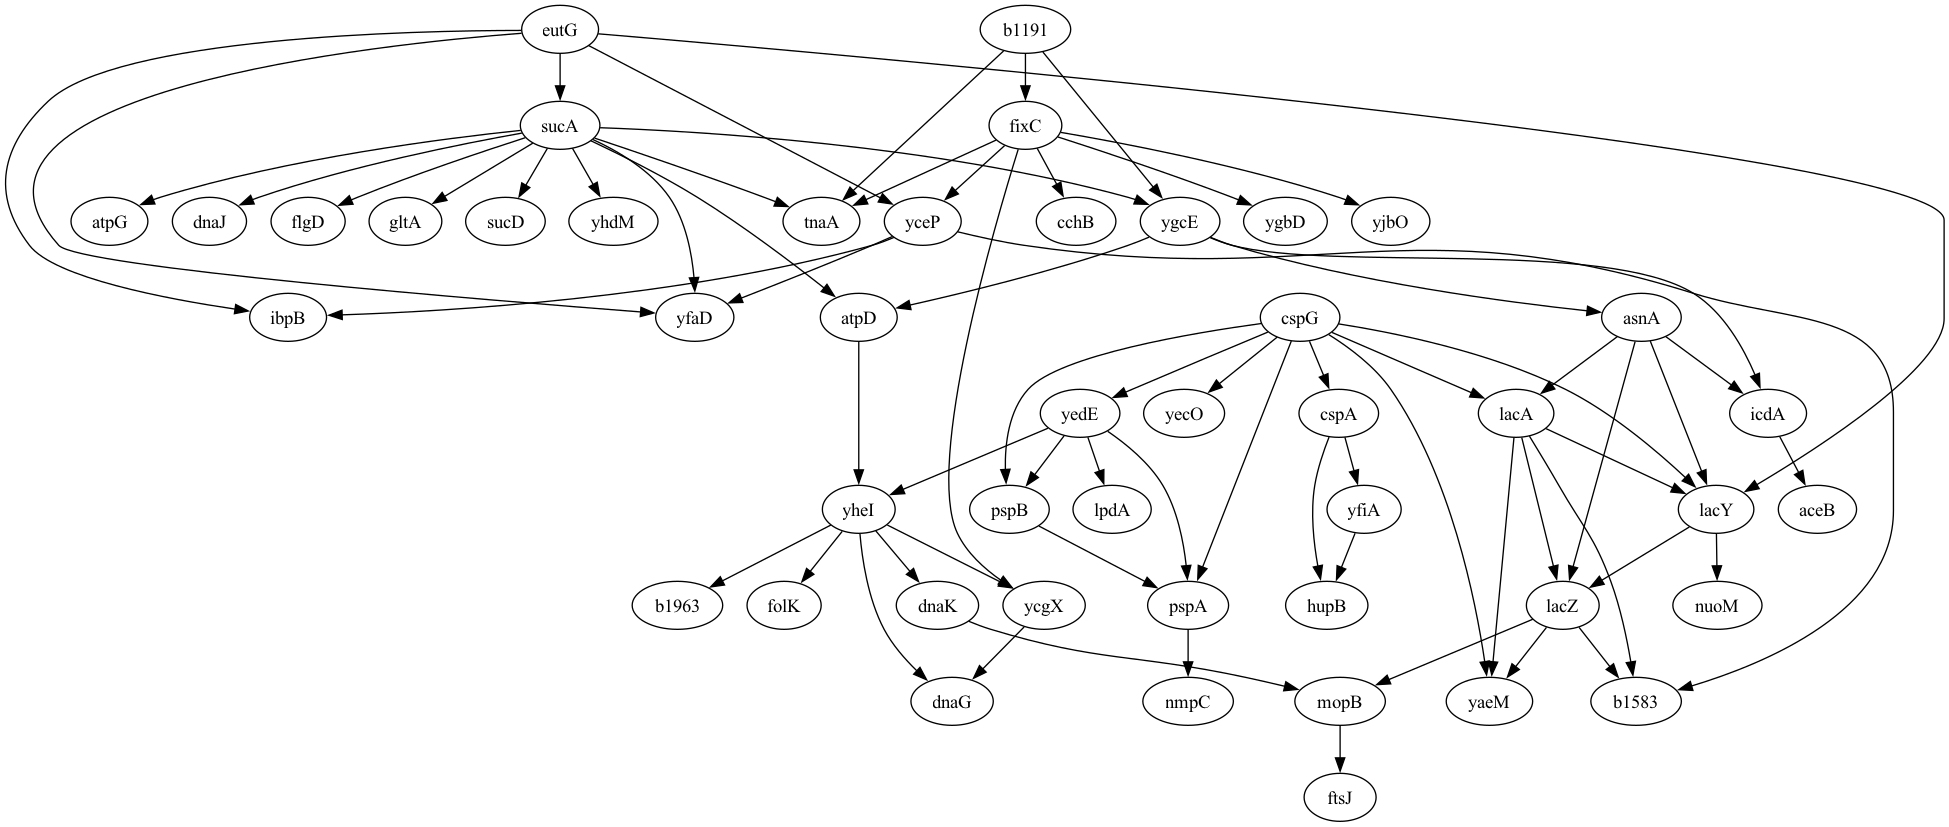

In [2]:
from IPython.display import Image
from pgmpy.utils import get_example_model

# Load the model
ecoli_model = get_example_model('ecoli70')

# get nodes and edges
nodes = ecoli_model.nodes()
print(f'{len(nodes)} nodes in the E. coli model.')
edges = ecoli_model.edges()
print(f'{len(edges)} edges in the E. coli model.')
cpds = ecoli_model.get_cpds()

# Visualize the network
viz = ecoli_model.to_graphviz()
viz.draw(IMAGE_DIR / 'ecoli.png', prog='dot')
Image(IMAGE_DIR / 'ecoli.png')

In [ ]:
# put this into a tigramite model

from tigramite.data_processing import DataFrame
from tigramite.toymodels.structural_causal_processes import structural_causal_process

# Define links: {effect_var: [((cause_var, lag), coef, noise_func), ...]}
# links = {
#     0: [((0, -1), 0.7, None), ((1, -1), 0.3, None)],
#     1: [((1, -1), 0.8, None)],
# }

def generate_links_from_pgmpy_model(model, noise_sd=1.0, coef=0.5, ar_param=0.6):
    nodes, edges = model.nodes(), model.edges()
    noise_func = lambda x: x + norm.rvs(scale=noise_sd)
    links = {}

    # create dicts mapping node names to indices and vice versa
    node_to_index = {node: idx for idx, node in enumerate(nodes)}
    index_to_node = {idx: node for node, idx in node_to_index.items()}

    # add edges from the pgmpy model
    for edge in edges:
        cause = node_to_index[edge[0]]
        effect = node_to_index[edge[1]]
        # for simplicity, use lag 1, constant coef and normal noise
        links.setdefault(effect, []).append( ((cause, -1), coef, noise_func) )

    # add a self-connection to all nodes to simulate autoregressive behavior
    for node in nodes:
        idx = node_to_index[node]
        links.setdefault(idx, []).append( ((idx, -1), ar_param, noise_func) )

    return links, node_to_index, index_to_node

def generate_data(model, noise_sd=3, tslength=500, seed=42):
    links, node_to_index, index_to_node = generate_links_from_pgmpy_model(model, 
        noise_sd=noise_sd)
    data, _ = structural_causal_process(links, T=tslength, seed=seed)

    # Prepare data for tigramite
    return DataFrame(data), index_to_node

# we will need the indx_to_node mapping later
ecoli_dataframe, index_to_node = generate_data(ecoli_model, noise_sd=3, tslength=500, seed=42)

In [11]:
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

def run_pcmci(dataframe):
    # Initialize PCMCI with partial correlation-based independence test
    pcmci = PCMCI(dataframe=dataframe, cond_ind_test=ParCorr())
    # Run PCMCI to discover causal links
    results = pcmci.run_pcmci(tau_max=1, pc_alpha=None)
    # get FDR-corrected p-values
    results['fdr_p_matrix'] = pcmci.get_corrected_pvalues(
        p_matrix=results['p_matrix'], fdr_method='fdr_bh')
    return results

results = run_pcmci(ecoli_dataframe)

In [12]:
# create tuples of x/y pairs from the results
def extract_discovered_links(results, index_to_node, q_thresh=0.00001):
    discovered_links = []
    fdr_p = results['fdr_p_matrix'][:, :, 1]  # use only lag 1 p-values
    links = np.where(fdr_p < q_thresh)
    for (i, j) in zip(links[0], links[1]):
        if not i == j:
            discovered_links.append((index_to_node[i], index_to_node[j]))
    return discovered_links

discovered_links = extract_discovered_links(results, index_to_node, .01)

In [13]:
def get_edge_stats(edges, discovered_links, verbose=True):
    true_edges = set(edges)
    discovered_edges = set(discovered_links)
    true_positives = true_edges.intersection(discovered_edges)
    false_positives = discovered_edges.difference(true_edges)
    false_negatives = true_edges.difference(discovered_edges)

    true_positive_rate = len(true_positives) / len(true_edges)
    false_positive_rate = len(false_positives) / len(discovered_edges)
    f1_score = (2 * len(true_positives)) / (2 * len(true_positives) + \
        len(false_positives) + len(false_negatives))
    
    if verbose:
        print(f'{len(true_edges)} true edges')
        print(f'discovered {len(discovered_edges)} edges')
        print(f"True Positive Rate: {true_positive_rate:.2%}")
        print(f"False Positive Rate: {false_positive_rate:.2%}")
        print(f"F1 Score: {f1_score:.2%}")

    return {
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'true_positive_rate': true_positive_rate,
        'false_positive_rate': false_positive_rate,
        'f1_score': f1_score
    }

edge_stats = get_edge_stats(ecoli_model.edges(), discovered_links)

70 true edges
discovered 72 edges
True Positive Rate: 100.00%
False Positive Rate: 2.78%
F1 Score: 98.59%


In [ ]:
# loop over noise levels and q values to see effect on performance

noise_sd = 10
tslengths = [100, 200, 500]
# use from 10e-5 to 10e-1
q_values =  [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

performance_results = []

for tslength in tslengths:
    dataframe = generate_data(ecoli_model, noise_sd=noise_sd, tslength=tslength, seed=42)
    results = run_pcmci(dataframe)
    for q in q_values:
        discovered_links = extract_discovered_links(results, index_to_node, q_thresh=q)
        edge_stats = get_edge_stats(ecoli_model.edges(), discovered_links, verbose=False)
        performance_results.append({
        'noise_sd': noise_sd,
        'q_value': q,
        'tslength': tslength,
        'true_positive_rate': edge_stats['true_positive_rate'],
        'false_positive_rate': edge_stats['false_positive_rate'],
        'f1_score': edge_stats['f1_score']
    })

performance_df = pd.DataFrame(performance_results)

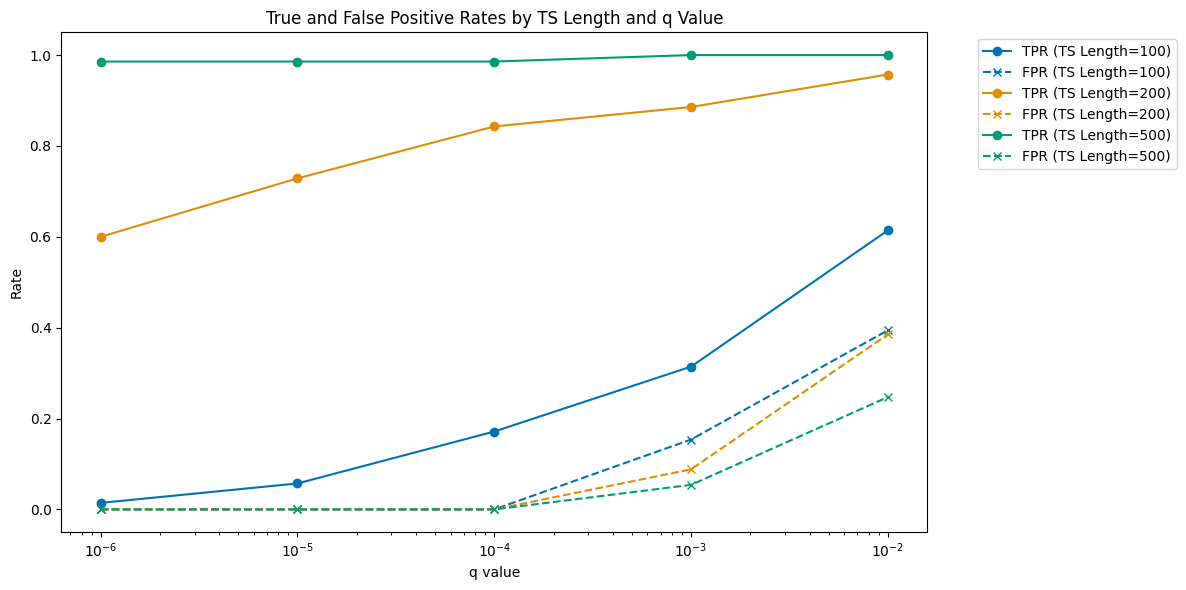

In [ ]:
# plot true and false positive rates as a function of tslength and q value
# use log scale for q value
# use a colorblind-friendly palette


# Use colorblind-friendly palette
colors = sns.color_palette("colorblind", n_colors=len(tslengths))

plt.figure(figsize=(12, 6))
for idx, tslength in enumerate(tslengths):
    subset = performance_df[performance_df['tslength'] == tslength]
    plt.plot(subset['q_value'], subset['true_positive_rate'], 
             marker='o', color=colors[idx], linestyle='-',
             label=f'TPR (TS Length={tslength})')
    plt.plot(subset['q_value'], subset['false_positive_rate'], 
             marker='x', color=colors[idx], linestyle='--',
             label=f'FPR (TS Length={tslength})')

plt.xscale('log')
plt.xlabel('q value')
plt.ylabel('Rate')
plt.title('True and False Positive Rates by TS Length and q Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'causal_discovery_performance.png', dpi=150, bbox_inches='tight')
plt.show()
